# Activation diagnostics for polynomial emulation

The Legendre basis is orthonormal for $d\rho_L=dx/2$, with
$\psi_n^L=\sqrt{2n+1}P_n$. The Chebyshev basis is orthonormal for
$d\rho_C=dx/(\pi\sqrt{1-x^2})$, with $\psi_0^C=1$ and
$\psi_n^C=\sqrt{2}T_n$ for $n\geq1$.

For each family, the ReLU, tanh, and RePU-2 constructions evaluate the same
normalized root factorization. ReLU and tanh multiplication are approximate;
RePU-2 multiplication is algebraically exact up to floating-point roundoff.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    ChebyshevEmulator,
    LegendreEmulator,
    basis_error_by_degree,
    emulated_chebyshev_basis,
    emulated_legendre_basis,
    exact_chebyshev_basis,
    exact_legendre_basis,
    relative_frobenius_mismatch,
)

FAMILIES = ("legendre", "chebyshev")
PRODUCTS = ("relu", "tanh", "repu2")
TANH_TOLERANCE = 1e-4

FAMILY_APIS = {
    "legendre": {
        "label": "Legendre",
        "emulator": LegendreEmulator,
        "exact_basis": exact_legendre_basis,
        "emulated_basis": emulated_legendre_basis,
        "sample": lambda rng, size: rng.uniform(-1.0, 1.0, size=size),
    },
    "chebyshev": {
        "label": "Chebyshev",
        "emulator": ChebyshevEmulator,
        "exact_basis": exact_chebyshev_basis,
        "emulated_basis": emulated_chebyshev_basis,
        "sample": lambda rng, size: np.cos(rng.uniform(0.0, np.pi, size=size)),
    },
}


## Pointwise basis error


In [2]:
rows = []
for family in FAMILIES:
    for product in PRODUCTS:
        errors = basis_error_by_degree(
            16,
            family=family,
            product=product,
            num_layers=12,
            tanh_step=None,
            tanh_tolerance=TANH_TOLERANCE,
            grid_size=2001,
        )
        rows.extend(
            {
                "family": family,
                "degree": degree,
                "product": product,
                "sup_error": error,
            }
            for degree, error in enumerate(errors)
        )
error_table = pd.DataFrame(rows)
error_table.pivot(index="degree", columns=("family", "product"), values="sup_error")


family       legendre                                 chebyshev                \
product          relu          tanh         repu2          relu          tanh   
degree                                                                          
0        0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1        0.000000e+00  0.000000e+00  0.000000e+00  2.220446e-16  2.220446e-16   
2        9.362618e-07  2.083048e-06  1.332268e-15  6.904425e-07  1.177945e-06   
3        1.276717e-05  5.994677e-06  3.996803e-15  1.170200e-05  1.667721e-06   
4        1.068409e-04  1.856466e-06  1.199041e-14  8.317924e-05  7.474617e-07   
5        8.336835e-04  2.295992e-06  2.620126e-14  7.168604e-04  6.175614e-07   
6        6.251628e-03  3.684726e-06  5.440093e-14  6.129590e-03  8.876967e-07   
7        4.807105e-02  3.313735e-06  1.287859e-13  4.596104e-02  7.786838e-07   
8        3.939169e-01  1.308648e-06  3.347322e-13  3.426405e-01  4.331925e-07   
9        3.474269e+00  9.002169e-07  8.051337e-13  3.144086e+00  4.354897e-07   
10       2.461365e+01  1.583464e-06  2.100431e-12  2.142889e+01  3.587155e-07   
11       1.928139e+02  1.581579e-06  6.654011e-12  1.708382e+02  3.417080e-07   
12       1.632362e+03  2.045790e-06  1.539591e-11  1.435956e+03  4.751932e-07   
13       1.304638e+04  6.059947e-07  3.436251e-11  1.137987e+04  1.665791e-07   
14       1.034279e+05  2.074777e-06  9.761880e-11  9.183618e+04  4.129876e-07   
15       9.700474e+05  1.666411e-06  2.563074e-10  8.643590e+05  2.309624e-07   
16       6.667148e+06  7.731149e-07  4.587208e-10  5.920965e+06  2.363253e-07   

family                 
product         repu2  
degree                 
0        0.000000e+00  
1        2.220446e-16  
2        1.110223e-15  
3        2.886580e-15  
4        6.217249e-15  
5        1.465494e-14  
6        6.283862e-14  
7        1.001421e-13  
8        2.600142e-13  
9        7.507328e-13  
10       2.327250e-12  
11       4.472422e-12  
12       1.428058e-11  
13       4.008582e-11  
14       6.149525e-11  
15       2.612464e-10  
16       6.097464e-10

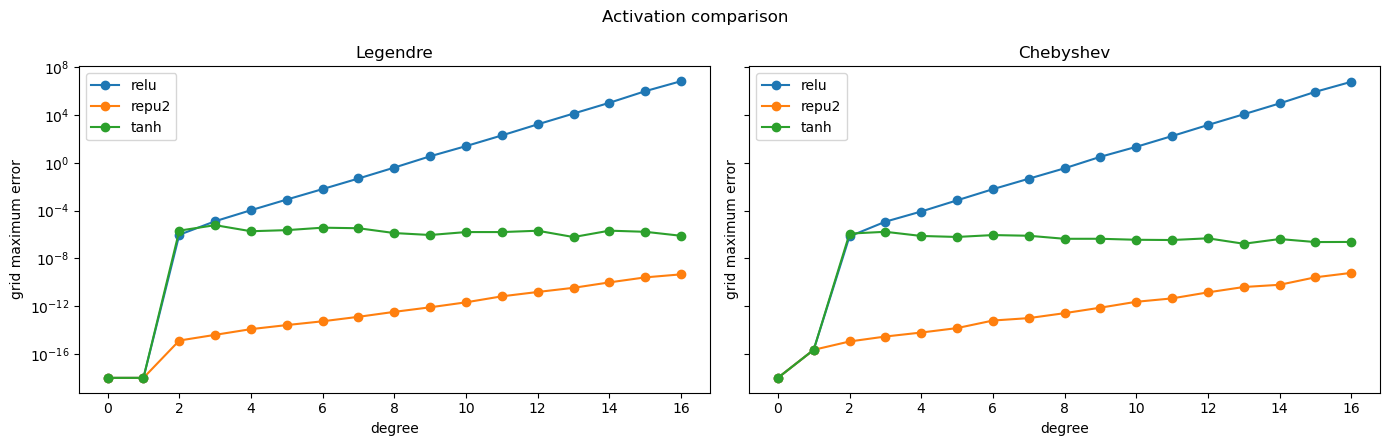

In [3]:
fig, axes = plt.subplots(1, len(FAMILIES), figsize=(14, 4.5), sharey=True)
for ax, family in zip(axes, FAMILIES):
    family_table = error_table[error_table["family"] == family]
    for product, group in family_table.groupby("product"):
        ax.semilogy(
            group["degree"],
            np.maximum(group["sup_error"], 1e-18),
            marker="o",
            label=product,
        )
    ax.set(
        xlabel="degree",
        ylabel="grid maximum error",
        title=FAMILY_APIS[family]["label"],
    )
    ax.legend()
fig.suptitle("Activation comparison")
fig.tight_layout()
plt.show()


## Measurement-matrix mismatch

Legendre samples are uniform on $[-1,1]$. Chebyshev samples have the form
$x=\cos\theta$, where $\theta$ is uniform on $[0,\pi]$. Thus each
measurement matrix is sampled from the probability measure defining its
orthonormal basis.


In [4]:
rng = np.random.default_rng(90210)
rows = []
for family in FAMILIES:
    api = FAMILY_APIS[family]
    samples = api["sample"](rng, 512)
    for max_degree in (4, 8, 12, 16, 24):
        exact = api["exact_basis"](samples, max_degree)
        for product in PRODUCTS:
            approximate = api["emulated_basis"](
                samples,
                max_degree,
                product=product,
                num_layers=12,
                tanh_step=None,
                tanh_tolerance=TANH_TOLERANCE,
            ).numpy()
            rows.append({
                "family": family,
                "max_degree": max_degree,
                "product": product,
                "relative_frobenius_mismatch": relative_frobenius_mismatch(
                    exact, approximate
                ),
            })
matrix_table = pd.DataFrame(rows)
matrix_table.pivot(
    index="max_degree",
    columns=("family", "product"),
    values="relative_frobenius_mismatch",
)


family          legendre                                 chebyshev  \
product             relu          tanh         repu2          relu   
max_degree                                                           
4           1.944380e-05  5.748235e-07  1.471183e-15  1.721408e-05   
8           6.363846e-02  4.768410e-07  1.703894e-14  5.404155e-02   
12          2.238103e+02  4.016001e-07  5.689216e-13  1.577372e+02   
16          6.127481e+05  3.526435e-07  1.651273e-11  6.132044e+05   
24          1.134912e+13  2.913010e-07  1.797107e-08  1.029681e+13   

family                                  
product             tanh         repu2  
max_degree                              
4           4.377035e-07  8.079788e-16  
8           3.742908e-07  1.945292e-14  
12          3.251488e-07  7.080838e-13  
16          2.880574e-07  2.240702e-11  
24          2.388397e-07  3.179139e-08

## Tanh step-size sensitivity

The explicit-step sweep exposes the truncation/cancellation tradeoff. The
package default allocates the requested tolerance over the product tree and
chooses a dtype-aware step at each node.


family      legendre                                 chebyshev                \
degree            8             16            24            8             16   
step                                                                           
0.001   4.386578e-08  1.278068e-07  6.307951e-07  3.317263e-08  7.612289e-08   
0.002   1.081631e-08  3.743395e-08  1.264459e-07  7.225155e-09  2.532191e-08   
0.005   1.565487e-09  6.303541e-09  1.185516e-08  1.227549e-09  5.157585e-09   
0.010   5.570357e-09  2.002635e-08  3.186763e-08  1.933643e-09  3.569081e-09   
0.020   9.006867e-08  2.777786e-07  5.368829e-07  2.778678e-08  6.312058e-08   
0.050   3.520962e-06  1.084687e-05  2.103182e-05  1.086254e-06  2.465949e-06   
0.100   5.629973e-05  1.734314e-04  3.362602e-04  1.736991e-05  3.943050e-05   
0.200   8.983724e-04  2.766587e-03  5.362275e-03  2.772315e-04  6.291222e-04   
0.400   1.418719e-02  4.354888e-02  8.409507e-02  4.383307e-03  9.915622e-03   

family                
degree            24  
step                  
0.001   3.460012e-07  
0.002   4.506437e-08  
0.005   8.802891e-09  
0.010   6.405024e-09  
0.020   9.886660e-08  
0.050   3.857894e-06  
0.100   6.168566e-05  
0.200   9.840092e-04  
0.400   1.547101e-02

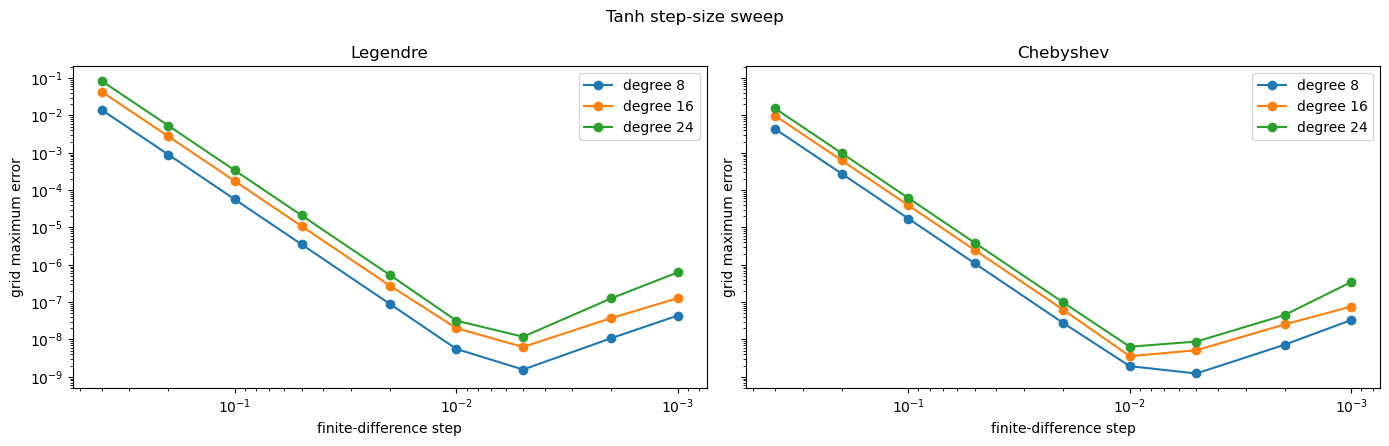

{'legendre': {8: ((0.0294015850406182,
    0.0329733052470935,
    0.024339248615745053,
    0.031694055254752544),
   (0.03477492023267557, 0.044153608720645186),
   (0.05069152584342976,)),
  16: ((0.01637158218740146,
    0.01739819412650879,
    0.017680168770082185,
    0.02026696342313996,
    0.015928897242614048,
    0.019775726732887723,
    0.013259945936712514,
    0.017927619571921127),
   (0.022854926736411003,
    0.025955706426624862,
    0.018802550076981457,
    0.02495683383918661),
   (0.02679617420086117, 0.03412858227679257),
   (0.03876729563891554,)),
  24: ((0.01162097742778505,
    0.012112722947207135,
    0.015293516187115825,
    0.01677939586220329,
    0.012102902871153424,
    0.013996247402494437,
    0.011257734317539327,
    0.013745944595919077,
    0.01323885690118092,
    0.01710585343949172,
    0.009303344885076215,
    0.012757033713595028),
   (0.016180564659231553,
    0.017655887453696024,
    0.018843533599065907,
    0.022784307113857396,
  

In [5]:
sweep_rows = []
for family in FAMILIES:
    for degree in (8, 16, 24):
        for step in (0.4, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001):
            error = basis_error_by_degree(
                degree,
                family=family,
                product="tanh",
                tanh_step=step,
                grid_size=2001,
            )[degree]
            sweep_rows.append({
                "family": family,
                "degree": degree,
                "step": step,
                "sup_error": error,
            })
sweep_table = pd.DataFrame(sweep_rows)
display(
    sweep_table.pivot(
        index="step", columns=("family", "degree"), values="sup_error"
    )
)

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(14, 4.5), sharey=True)
for ax, family in zip(axes, FAMILIES):
    family_table = sweep_table[sweep_table["family"] == family]
    for degree, group in family_table.groupby("degree"):
        ax.loglog(
            group["step"], group["sup_error"], marker="o", label=f"degree {degree}"
        )
    ax.invert_xaxis()
    ax.set(
        xlabel="finite-difference step",
        ylabel="grid maximum error",
        title=FAMILY_APIS[family]["label"],
    )
    ax.legend()
fig.suptitle("Tanh step-size sweep")
fig.tight_layout()
plt.show()

automatic_steps = {
    family: {
        degree: FAMILY_APIS[family]["emulator"](
            degree, product="tanh", tanh_tolerance=TANH_TOLERANCE
        ).tanh_steps(torch.float64)
        for degree in (8, 16, 24)
    }
    for family in FAMILIES
}
automatic_steps


RePU-2 isolates floating-point conditioning of the root factorization because
its binary products are algebraically exact. The ReLU curve also contains the
accumulated approximation error of its squaring networks. The tanh curve uses
finite-difference multiplication and a bound-aware product tree.
